In [ ]:
# Run this cell to Download dataset
!gdown 18eEEtko63fth0HEIFdxEdbjR4DfXiPa7

Downloading...
From: https://drive.google.com/uc?id=18eEEtko63fth0HEIFdxEdbjR4DfXiPa7
To: /content/processed_purchase_propensity_data_v1.parquet
100% 58.0M/58.0M [00:01<00:00, 30.9MB/s]


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_parquet("./processed_purchase_propensity_data_v1.parquet")

## Kiểm tra độ lớn của data


In [ ]:
df.shape

(2933439, 11)

## Kiểm tra thông tin chung của DataFrame


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2933439 entries, 0 to 2933438
Data columns (total 11 columns):
 #   Column                Dtype         
---  ------                -----         
 0   user_id               int64         
 1   product_id            int64         
 2   event_timestamp       datetime64[ns]
 3   created_timestamp     datetime64[us]
 4   category_code_level1  object        
 5   category_code_level2  object        
 6   brand                 object        
 7   event_weekday         int64         
 8   price                 float64       
 9   activity_count        int64         
 10  is_purchased          int64         
dtypes: datetime64[ns](1), datetime64[us](1), float64(1), int64(5), object(3)
memory usage: 246.2+ MB


## Kiểm tra các giá trị thiếu (Missing Values)


In [ ]:
df.isnull().sum()

,0
user_id,0
product_id,0
event_timestamp,0
created_timestamp,0
category_code_level1,0
category_code_level2,0
brand,0
event_weekday,0
price,0
activity_count,0


##Xóa cột dữ liệu thừa created_timestamp

In [ ]:
df = df.drop(columns=['created_timestamp'])
df.shape

(2933439, 10)

## Hiển thị thống kê mô tả


In [ ]:
df.describe()

,user_id,product_id,event_timestamp,event_weekday,price,activity_count,is_purchased
count,2.933439e+06,2.933439e+06,2933439,2.933439e+06,2.933439e+06,2.933439e+06,2.933439e+06
mean,5.408460e+08,8.455282e+06,2019-11-17 20:30:47.724635904,3.777605e+00,2.905062e+02,8.280268e+00,2.602181e-01
min,7.438304e+07,1.000978e+06,2019-11-01 07:00:14,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,5.176743e+08,1.005100e+06,2019-11-15 08:15:53,3.000000e+00,7.439000e+01,2.000000e+00,0.000000e+00
50%,5.399510e+08,3.600163e+06,2019-11-16 20:54:20,4.000000e+00,1.687000e+02,5.000000e+00,0.000000e+00
75%,5.636370e+08,1.270302e+07,2019-11-20 21:46:49,5.000000e+00,3.497900e+02,9.000000e+00,1.000000e+00
max,5.799677e+08,1.000282e+08,2019-12-01 06:59:52,6.000000e+00,2.574070e+03,4.180000e+02,1.000000e+00
std,2.272728e+07,1.377809e+07,NaN,1.890691e+00,3.357733e+02,1.148055e+01,4.387536e-01


## Phân tích giá trị duy nhất và phân phối tần suất(các cột đối tượng và chuỗi)



In [ ]:
columns_to_analyze = ['category_code_level1', 'category_code_level2', 'brand', 'event_weekday', 'is_purchased']

for col in columns_to_analyze:
    print(f"\n--- Column: {col} ---")
    print(f"Number of unique values: {df[col].nunique()}")
    print("Frequency distribution:")
    print(df[col].value_counts())



--- Column: category_code_level1 ---
Number of unique values: 14
Frequency distribution:
category_code_level1
electronics     1476287
unknown          800775
appliances       339668
computers        115230
apparel           52863
furniture         40110
auto              38113
construction      35154
kids              20045
accessories        7367
sport              5596
medicine           1255
stationery          632
country_yard        344
Name: count, dtype: int64

--- Column: category_code_level2 ---
Number of unique values: 58
Frequency distribution:
category_code_level2
smartphone        1121377
unknown            800775
kitchen            223055
audio              145800
video              102954
environment         89497
clocks              67981
notebook            57579
shoes               46766
accessories         38113
tools               35098
peripherals         23095
tablet              21536
components          21409
living_room         16903
telephone           14355


##Kiểm tra các giá hàng đữ liệu bị trùng lặp

In [ ]:
df.duplicated().sum()

np.int64(0)

##Tách thời gian từ event_timestamp ra thành giờ xảy ra sự kiện(event_hour)

In [ ]:
df['event_hour'] = df['event_timestamp'].dt.hour
df.head()

,user_id,product_id,event_timestamp,category_code_level1,category_code_level2,brand,event_weekday,price,activity_count,is_purchased,event_hour
0,515903856,2601552,2019-11-17 00:11:39,unknown,unknown,gorenje,6,486.24,6,0,0
1,516301799,12702930,2019-11-12 15:40:15,unknown,unknown,cordiant,1,35.78,2,0,15
2,516301799,12702930,2019-11-12 15:41:46,unknown,unknown,cordiant,1,35.78,6,0,15
3,516301799,12702930,2019-11-12 15:42:05,unknown,unknown,cordiant,1,35.78,8,0,15
4,561066382,3800966,2019-11-15 23:36:25,appliances,iron,elenberg,4,20.57,2,0,23


## Phân tích phân phối của các biến số

### Subtask:
Tạo biểu đồ histogram cho các cột số `price` và `activity_count` để trực quan hóa phân phối của chúng. Nếu cần, cũng sẽ tạo box plot để xem xét phân phối và các giá trị ngoại lệ chi tiết hơn.


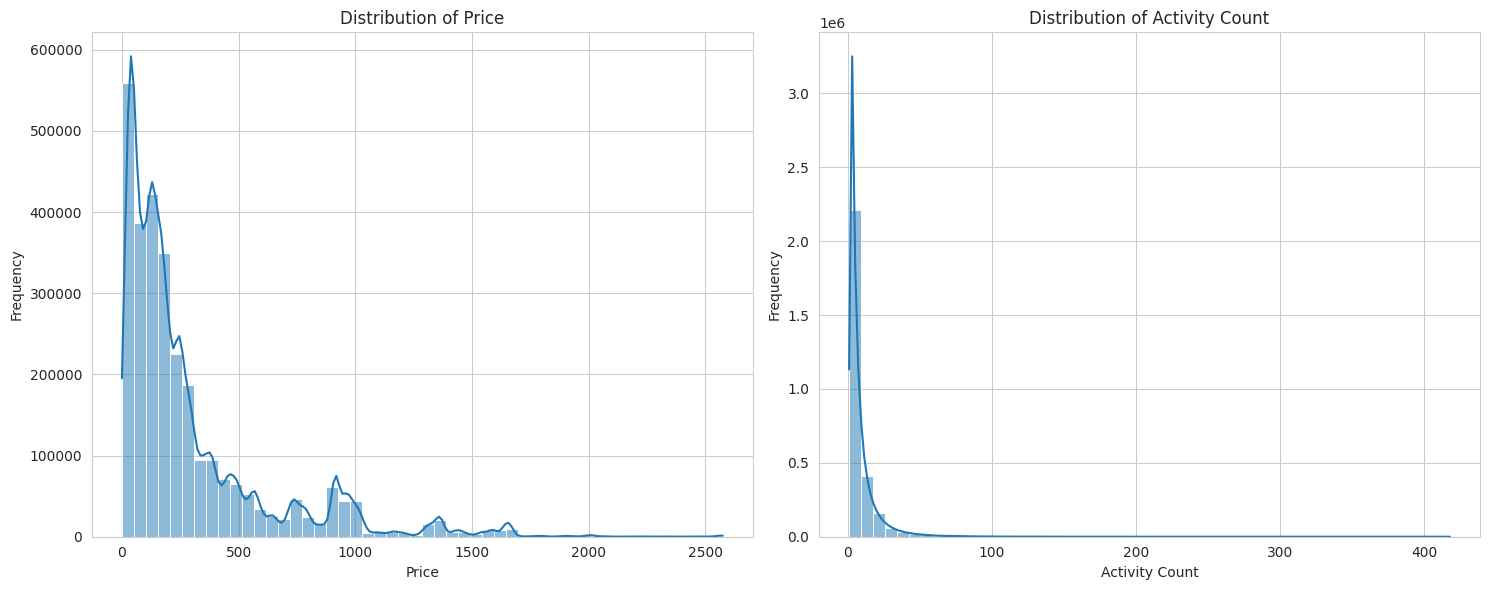

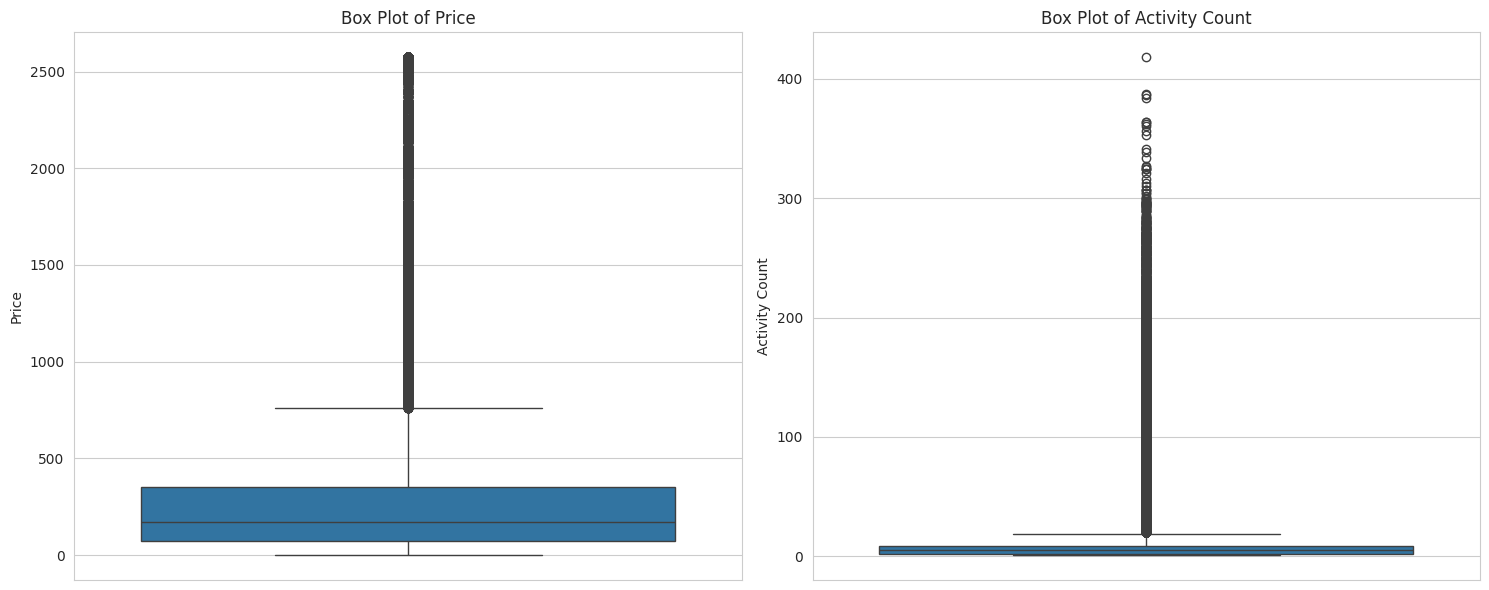

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
sns.set_style("whitegrid")

# Create a figure with subplots for histograms
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df['activity_count'], bins=50, kde=True)
plt.title('Distribution of Activity Count')
plt.xlabel('Activity Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Create a figure with subplots for box plots to check for outliers
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['price'])
plt.title('Box Plot of Price')
plt.ylabel('Price')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['activity_count'])
plt.title('Box Plot of Activity Count')
plt.ylabel('Activity Count')

plt.tight_layout()
plt.show()

Phân phối của giờ mà người dùng thực hiện thao tác thêm vào giỏ hàng và mua

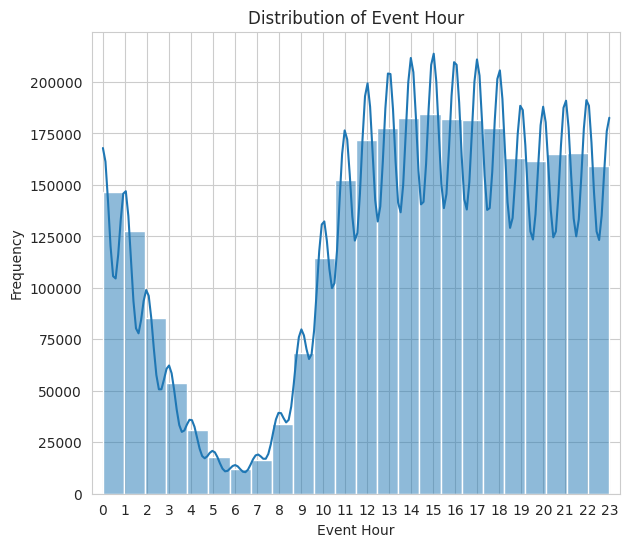

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['event_hour'], bins=24, kde=True)
plt.title('Distribution of Event Hour')
plt.xlabel('Event Hour')
plt.ylabel('Frequency')
plt.xticks(range(0, 24))
plt.xlim(-0.5, 23.5)
plt.show()

Tỉ lệ mua hàng theo giờ trong ngày

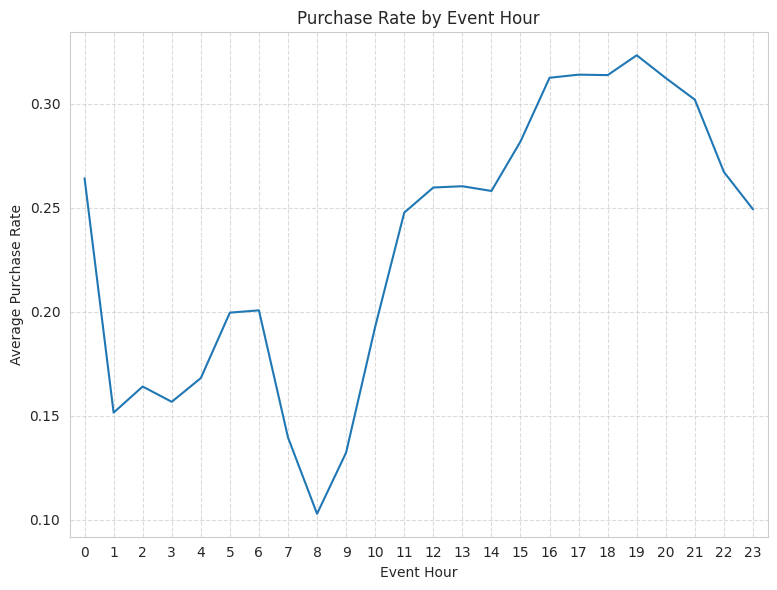

In [ ]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
purchase_rate_by_hour = df.groupby('event_hour')['is_purchased'].mean()
sns.lineplot(x=purchase_rate_by_hour.index, y=purchase_rate_by_hour.values)
plt.title('Purchase Rate by Event Hour')
plt.xlabel('Event Hour')
plt.ylabel('Average Purchase Rate')
plt.xticks(range(0, 24))
plt.xlim(-0.5, 23.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Phân tích mối quan hệ giữa các biến

### Subtask:
Trực quan hóa mối quan hệ giữa các biến số trong DataFrame `df`, bao gồm mối quan hệ giữa các biến số liên tục, biến số phân loại và biến thời gian.


**Reasoning**:
The first step is to convert the 'event_time' column to datetime objects and then set it as the DataFrame's index, as specified in the instructions. This is crucial for any time-based analysis and prepares the data for the subsequent visualization steps.



In [ ]:
df['event_time'] = pd.to_datetime(df['event_time'])
df = df.set_index('event_time')
print("Converted 'event_time' to datetime and set as index.")
print(df.head())

Converted 'event_time' to datetime and set as index.
                       user_id  product_id category_code_level1  \
event_time                                                        
2019-11-17 00:11:39  515903856     2601552              unknown   
2019-11-12 15:40:15  516301799    12702930              unknown   
2019-11-12 15:41:46  516301799    12702930              unknown   
2019-11-12 15:42:05  516301799    12702930              unknown   
2019-11-15 23:36:25  561066382     3800966           appliances   

                    category_code_level2     brand  event_weekday   price  \
event_time                                                                  
2019-11-17 00:11:39              unknown   gorenje              6  486.24   
2019-11-12 15:40:15              unknown  cordiant              1   35.78   
2019-11-12 15:41:46              unknown  cordiant              1   35.78   
2019-11-12 15:42:05              unknown  cordiant              1   35.78   
2019-11-15 23:3

**Reasoning**:
To continue visualizing the relationships between variables, I will create a scatter plot for 'price' and 'activity_count', and then generate two bar plots: one for the purchase rate per 'event_weekday' and another for the average price per 'category_code_level1', as per the instructions.



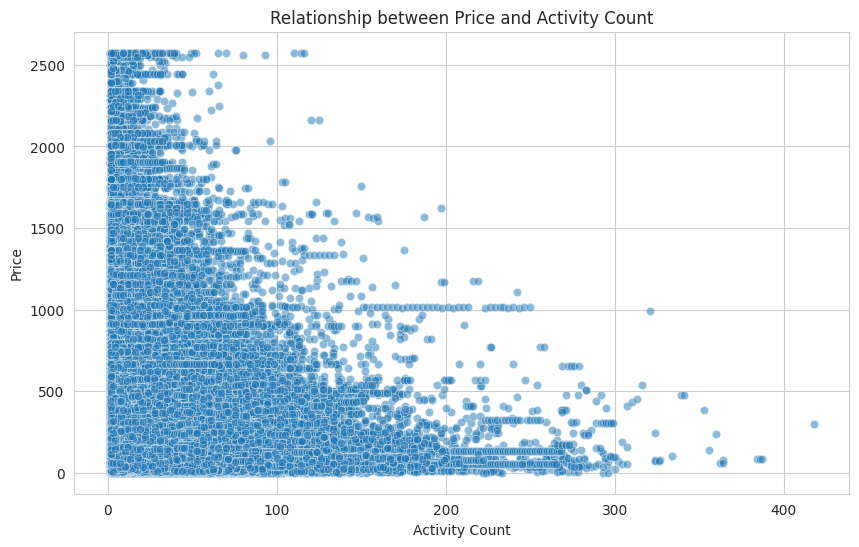

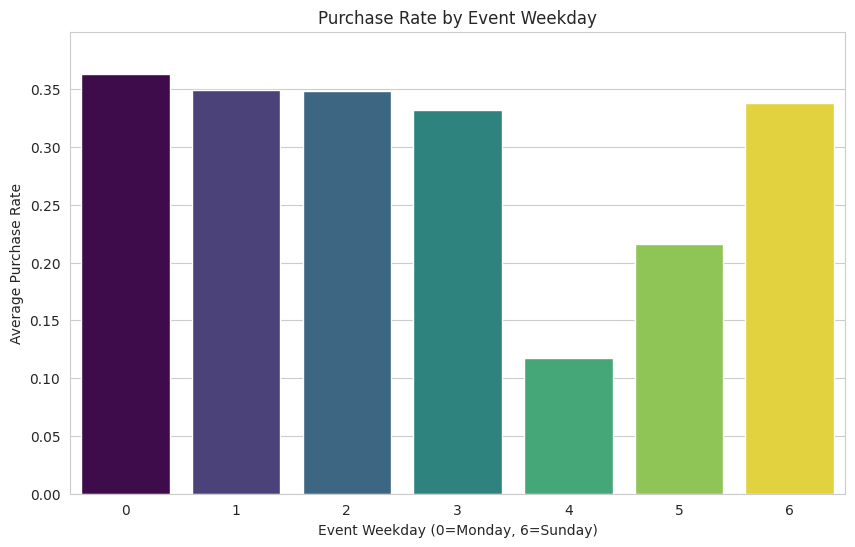

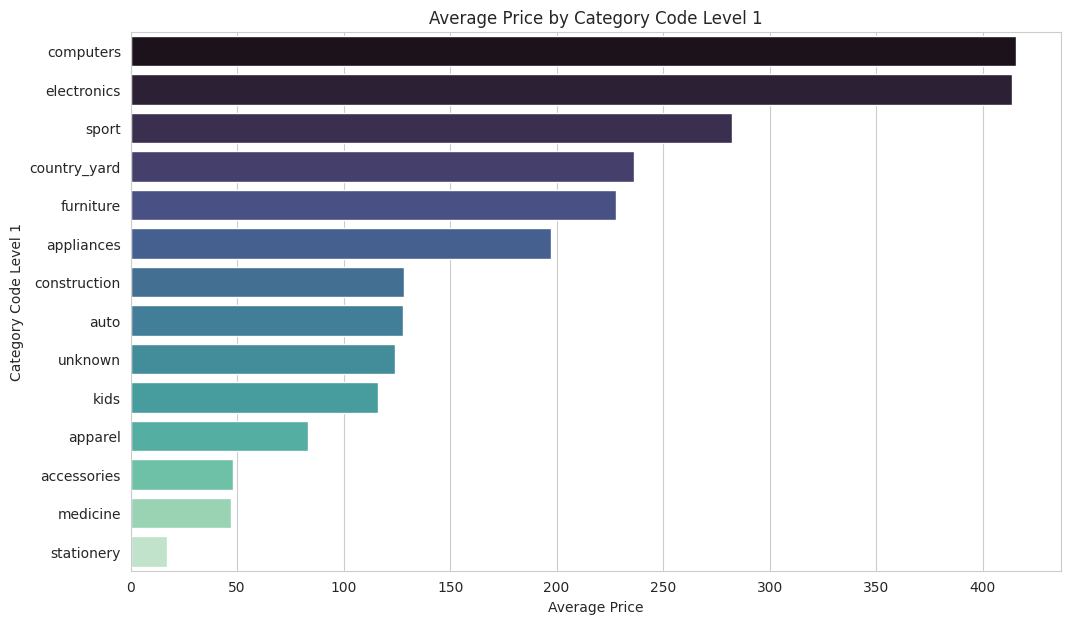

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 2. Scatter plot for Price vs Activity Count
plt.figure(figsize=(10, 6))
sns.scatterplot(x='activity_count', y='price', data=df, alpha=0.5)
plt.title('Relationship between Price and Activity Count')
plt.xlabel('Activity Count')
plt.ylabel('Price')
plt.show()

# 3. Bar plot for Purchase Rate by Event Weekday
purchase_rate_by_weekday = df.groupby('event_weekday')['is_purchased'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='event_weekday', y='is_purchased', data=purchase_rate_by_weekday, hue='event_weekday', palette='viridis', legend=False)
plt.title('Purchase Rate by Event Weekday')
plt.xlabel('Event Weekday (0=Monday, 6=Sunday)')
plt.ylabel('Average Purchase Rate')
plt.ylim(0, purchase_rate_by_weekday['is_purchased'].max() * 1.1) # Set y-axis limit for better visualization
plt.show()

# 4. Bar plot for Average Price by Category Code Level 1
avg_price_by_category1 = df.groupby('category_code_level1')['price'].mean().reset_index().sort_values(by='price', ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x='price', y='category_code_level1', data=avg_price_by_category1, hue='category_code_level1', palette='mako', legend=False)
plt.title('Average Price by Category Code Level 1')
plt.xlabel('Average Price')
plt.ylabel('Category Code Level 1')
plt.show()

## Trực quan hóa phân phối tần suất biến phân loại

### Subtask:
Tạo biểu đồ thanh (bar plots) để hiển thị phân phối tần suất của các biến phân loại `category_code_level1`, `event_weekday`, và `is_purchased`. Đối với `category_code_level2` và `brand`, tạo biểu đồ thanh chỉ hiển thị top 10 giá trị phổ biến nhất.


**Reasoning**:
I need to generate bar plots for the specified categorical variables, including top 10 distributions for 'category_code_level2' and 'brand', as requested in the subtask instructions.



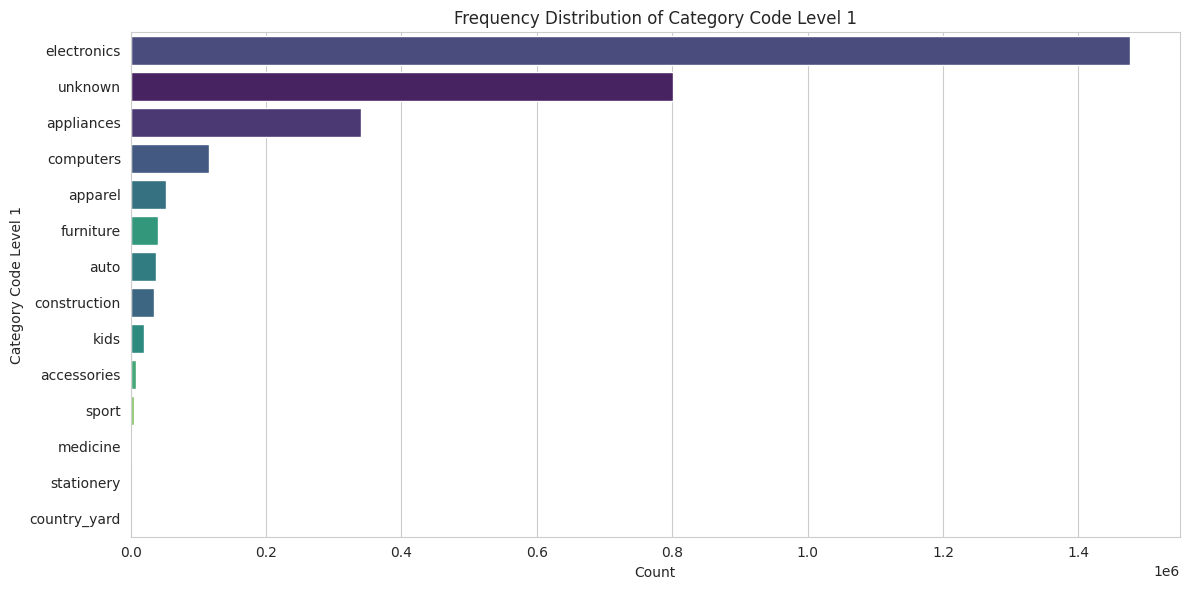

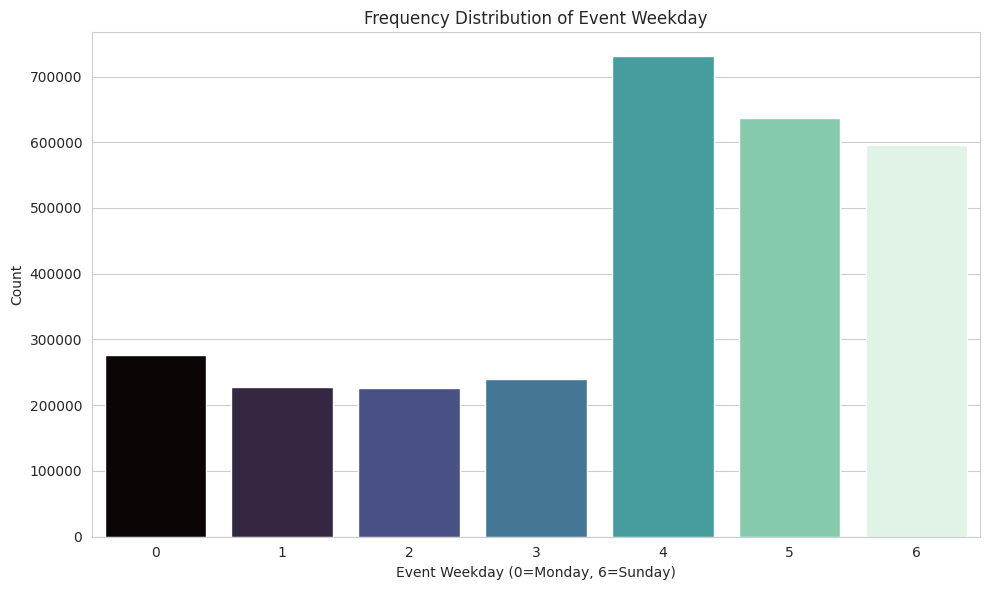

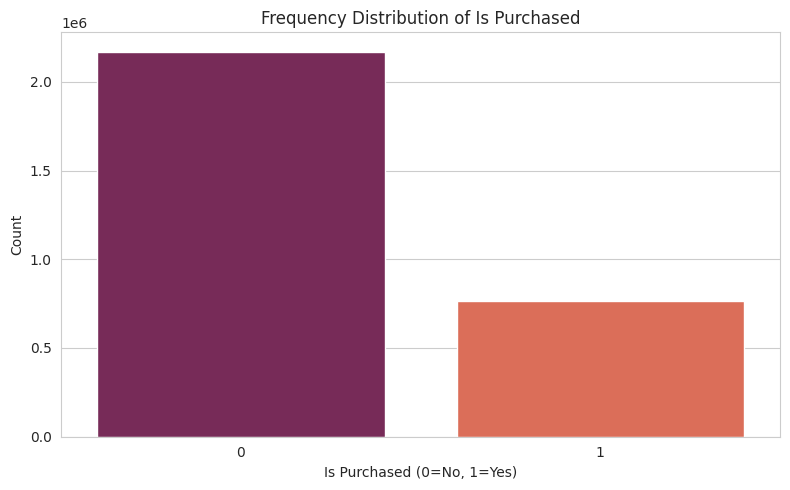

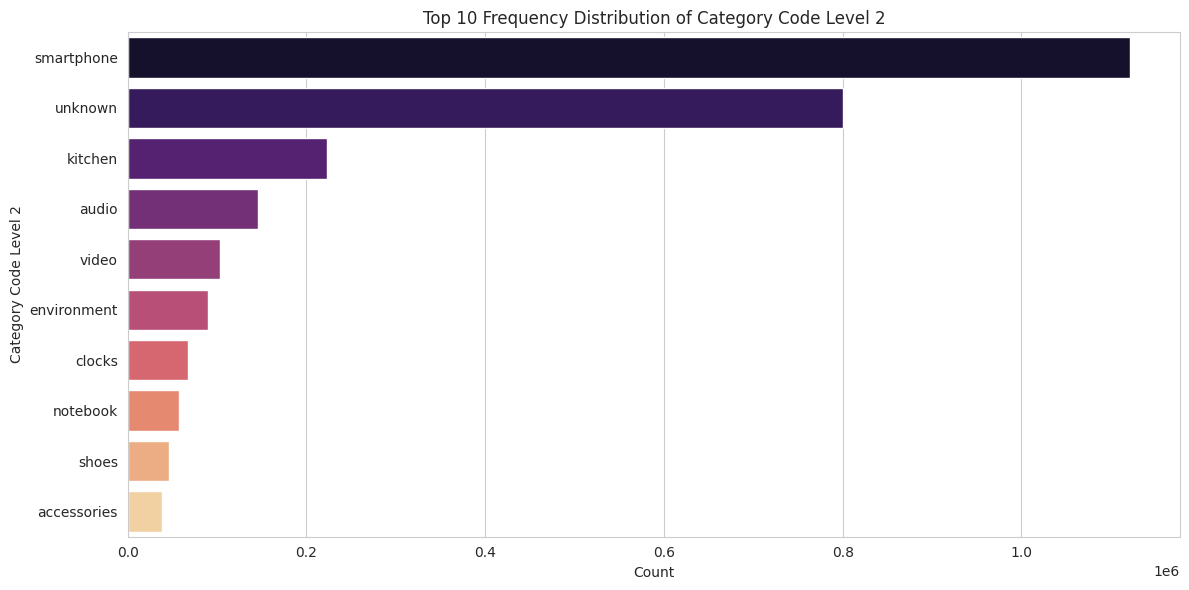

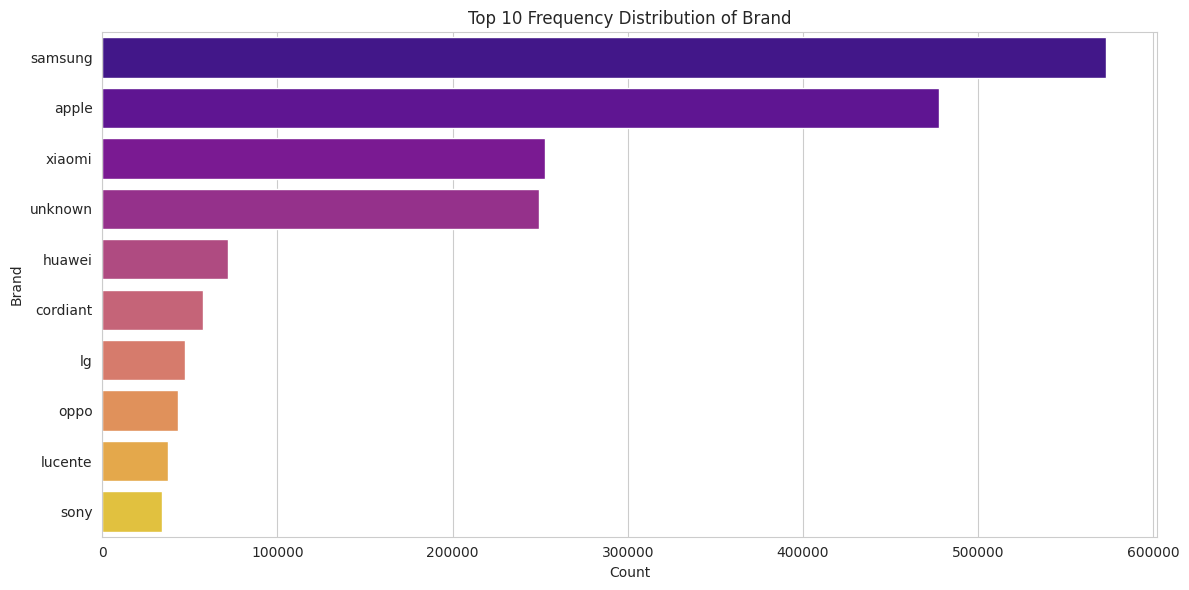

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Bar plot for category_code_level1
plt.figure(figsize=(12, 6))
sns.countplot(y='category_code_level1', data=df, order=df['category_code_level1'].value_counts().index, palette='viridis', hue='category_code_level1', legend=False)
plt.title('Frequency Distribution of Category Code Level 1')
plt.xlabel('Count')
plt.ylabel('Category Code Level 1')
plt.tight_layout()
plt.show()

# 2. Bar plot for event_weekday
plt.figure(figsize=(10, 6))
sns.countplot(x='event_weekday', data=df, palette='mako', hue='event_weekday', legend=False)
plt.title('Frequency Distribution of Event Weekday')
plt.xlabel('Event Weekday (0=Monday, 6=Sunday)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3. Bar plot for is_purchased
plt.figure(figsize=(8, 5))
sns.countplot(x='is_purchased', data=df, palette='rocket', hue='is_purchased', legend=False)
plt.title('Frequency Distribution of Is Purchased')
plt.xlabel('Is Purchased (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 4. Top 10 Bar plot for category_code_level2
top_10_category_code_level2 = df['category_code_level2'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_category_code_level2.values, y=top_10_category_code_level2.index, palette='magma', hue=top_10_category_code_level2.index, legend=False)
plt.title('Top 10 Frequency Distribution of Category Code Level 2')
plt.xlabel('Count')
plt.ylabel('Category Code Level 2')
plt.tight_layout()
plt.show()

# 5. Top 10 Bar plot for brand
top_10_brand = df['brand'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_brand.values, y=top_10_brand.index, palette='plasma', hue=top_10_brand.index, legend=False)
plt.title('Top 10 Frequency Distribution of Brand')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

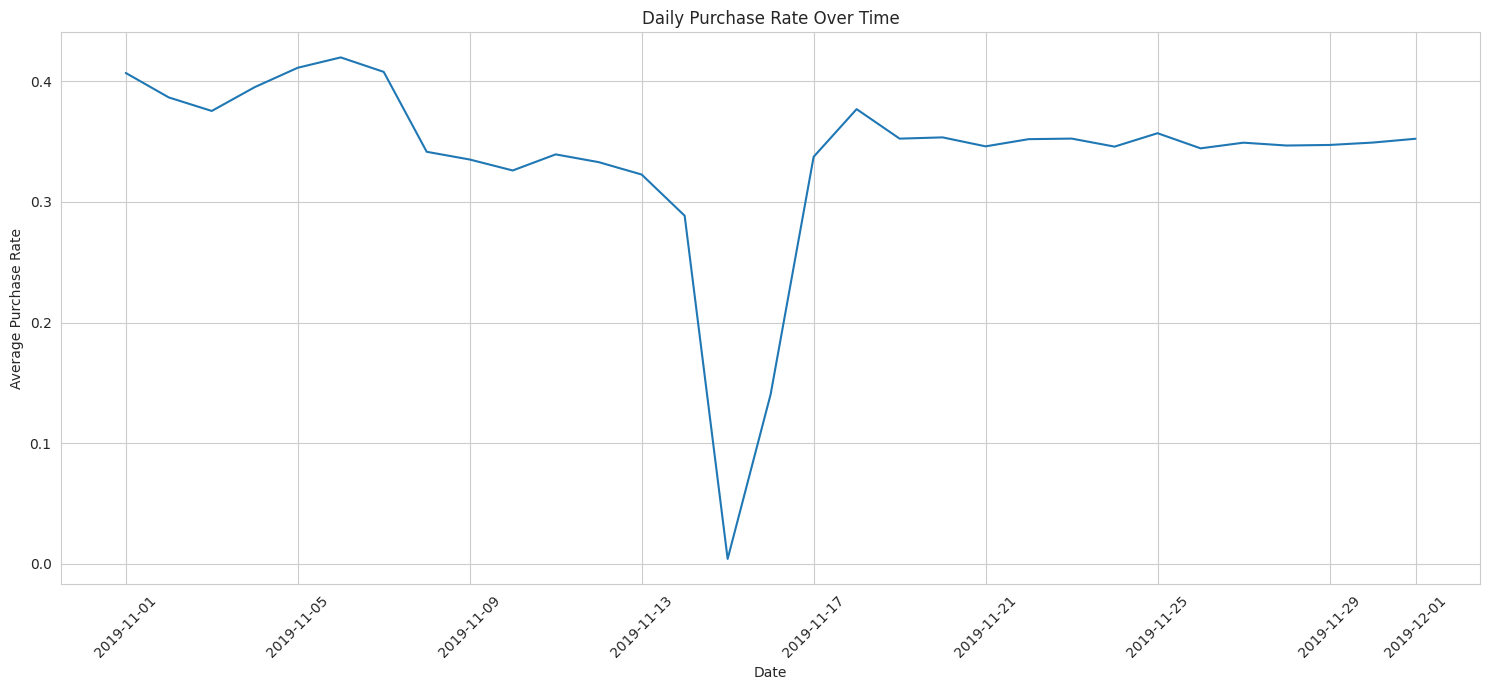

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 2. Scatter plot for Price vs Activity Count
plt.figure(figsize=(10, 6))
sns.scatterplot(x='activity_count', y='price', data=df, alpha=0.5)
plt.title('Relationship between Price and Activity Count')
plt.xlabel('Activity Count')
plt.ylabel('Price')
plt.show()

# 3. Bar plot for Purchase Rate by Event Weekday
purchase_rate_by_weekday = df.groupby('event_weekday')['is_purchased'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='event_weekday', y='is_purchased', data=purchase_rate_by_weekday, hue='event_weekday', palette='viridis', legend=False)
plt.title('Purchase Rate by Event Weekday')
plt.xlabel('Event Weekday (0=Monday, 6=Sunday)')
plt.ylabel('Average Purchase Rate')
plt.ylim(0, purchase_rate_by_weekday['is_purchased'].max() * 1.1) # Set y-axis limit for better visualization
plt.show()

# 4. Bar plot for Average Price by Category Code Level 1
avg_price_by_category1 = df.groupby('category_code_level1')['price'].mean().reset_index().sort_values(by='price', ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x='price', y='category_code_level1', data=avg_price_by_category1, hue='category_code_level1', palette='mako', legend=False)
plt.title('Average Price by Category Code Level 1')
plt.xlabel('Average Price')
plt.ylabel('Category Code Level 1')
plt.show()

##Mã hóa các cột dạng object và string để có cái nhìn tổng quan về quan hệ tuyến tính qua hệ số tương quan

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the DataFrame to avoid modifying the original for this operation
df_encoded = df.copy()

# Identify object columns for encoding
object_cols = df_encoded.select_dtypes(include=['object']).columns

# Apply Label Encoding to each object column
for col in object_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Column '{col}' encoded successfully.")

# Display the head of the encoded DataFrame to verify
display(df_encoded.head())

Column 'category_code_level1' encoded successfully.
Column 'category_code_level2' encoded successfully.
Column 'brand' encoded successfully.


,user_id,product_id,event_timestamp,category_code_level1,category_code_level2,brand,event_weekday,price,activity_count,is_purchased,event_hour
0,515903856,2601552,2019-11-17 00:11:39,13,55,1095,6,486.24,6,0,0
1,516301799,12702930,2019-11-12 15:40:15,13,55,608,1,35.78,2,0,15
2,516301799,12702930,2019-11-12 15:41:46,13,55,608,1,35.78,6,0,15
3,516301799,12702930,2019-11-12 15:42:05,13,55,608,1,35.78,8,0,15
4,561066382,3800966,2019-11-15 23:36:25,2,22,832,4,20.57,2,0,23


##Heatmap tương quan giữa các biến trong data frame

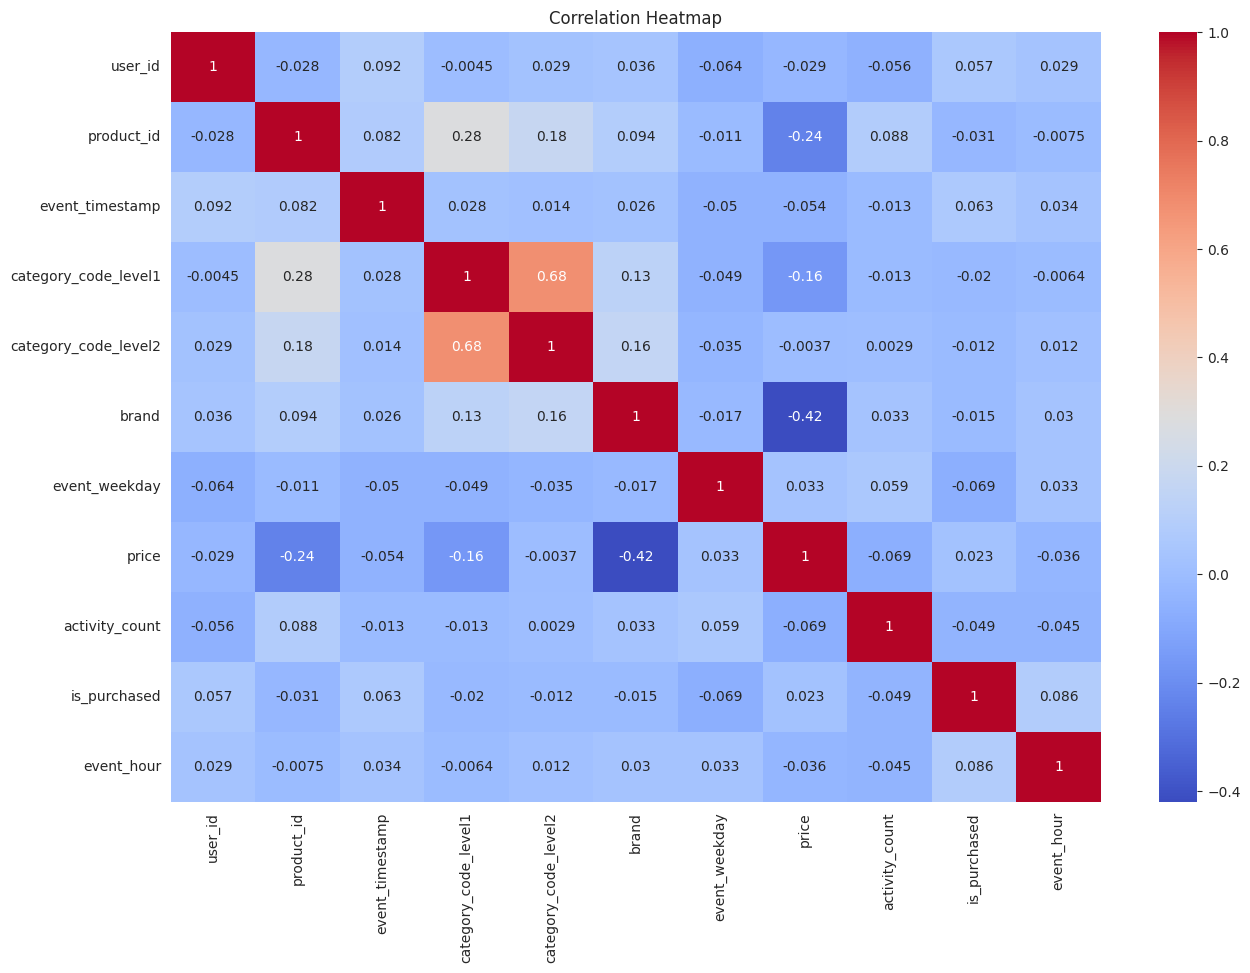

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()